In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import re

# Load the parsed table
df = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/data/0023_hairpin_structure_conservation_table.txt", sep="\t")
#df_most = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/most_conserved_top10pct_string.csv", sep="\t")
#df_medium = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/medium_conserved_top40pct_string.csv", sep="\t")
df_co = df[df["covariation"] < 0]
df_cov = df_co[df_co["num_seqs"] >= 29]
df_covariation = df_cov[df_cov["mean_structure"].notna()]

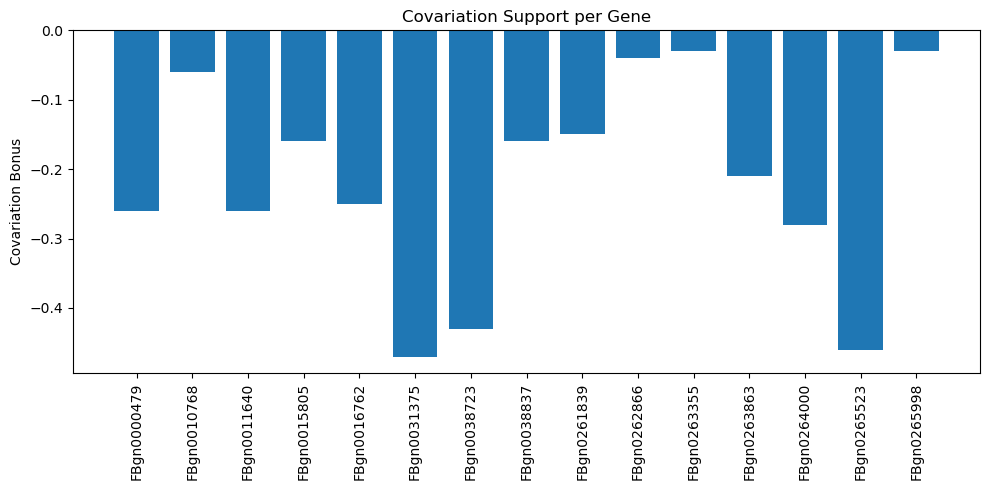

In [11]:
# Covariation bonues
plt.figure(figsize=(10, 5))
plt.bar(df_covariation["gene_id"], df_covariation["covariation"])
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Covariation Bonus")
plt.title("Covariation Support per Gene")
plt.tight_layout()
plt.show()

In [12]:
df_covariation
df_covariation.to_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/compensatory_mutations.tsv", sep="\t", index=False)


In [13]:
df_mediumx = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/medium_conserved_top40pct.csv", sep=",")
df_medium = []
for row in df_mediumx["alignment"]:
    if row.startswith('FBgn'):
        gene = row.split("_")
        df_medium.append(gene[0])
print(df_medium)

df_mostx = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/most_conserved_top10pct.csv", sep=",")
df_most = []
for row in df_mostx["alignment"]:
    if row.startswith('FBgn'):
        gene = row.split("_")
        df_most.append(gene[0])
print(df_most)

['FBgn0264005', 'FBgn0266435', 'FBgn0001297', 'FBgn0040208', 'FBgn0015805', 'FBgn0040687', 'FBgn0032021', 'FBgn0038855', 'FBgn0032129', 'FBgn0038541', 'FBgn0262866', 'FBgn0284237', 'FBgn0030260', 'FBgn0264000', 'FBgn0041105', 'FBgn0037218', 'FBgn0029503', 'FBgn0038089', 'FBgn0000479', 'FBgn0038837', 'FBgn0286813', 'FBgn0035092', 'FBgn0036829', 'FBgn0036008', 'FBgn0037655', 'FBgn0283442', 'FBgn0085390', 'FBgn0036896', 'FBgn0028848', 'FBgn0038300', 'FBgn0052137', 'FBgn0013303', 'FBgn0035753', 'FBgn0038723', 'FBgn0010226', 'FBgn0003137', 'FBgn0035688', 'FBgn0259145', 'FBgn0034012', 'FBgn0285917', 'FBgn0032896', 'FBgn0264442', 'FBgn0032120', 'FBgn0038852', 'FBgn0263846', 'FBgn0259832', 'FBgn0014163', 'FBgn0051876', 'FBgn0039417', 'FBgn0011818', 'FBgn0037746', 'FBgn0034030', 'FBgn0038511', 'FBgn0039858', 'FBgn0035490', 'FBgn0262483', 'FBgn0051108', 'FBgn0259108', 'FBgn0036070', 'FBgn0001123', 'FBgn0016691', 'FBgn0033935', 'FBgn0010768', 'FBgn0259937', 'FBgn0031190', 'FBgn0029587', 'FBgn0262

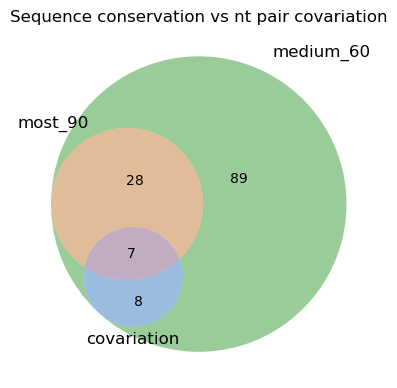

In [14]:
set_most   = set(df_most)
set_medium = set(df_medium)
set_covariation = set(df_covariation["gene_id"])

plt.figure(figsize=(4, 4))
venn3([set_most, set_medium, set_covariation], set_labels=('most_90', 'medium_60', 'covariation'))
plt.title("Sequence conservation vs nt pair covariation")
plt.tight_layout()
plt.show()

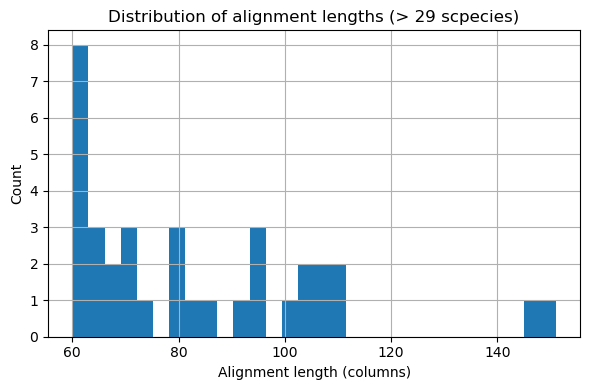

In [15]:
plt.figure(figsize=(6, 4))
df_mostx["aln_length"].hist(bins=30)
plt.xlabel("Alignment length (columns)")
plt.ylabel("Count")
plt.title("Distribution of alignment lengths (> 29 scpecies)")
plt.tight_layout()
plt.show()

In [ ]:
#df_flagged = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/flagged_conserved_codon_genes.tsv", sep="\t")
#df_codon = []
#for row in df_flagged["gene"]:
    #if row.startswith('FBgn'):
        #gene = row.split("_")
        #df_codon.append(gene[0])
#print(df_codon)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/alejandraescos/Documents/github/SCR/0003_hairpinConservation/results_figures/flagged_conserved_codon_genes.tsv'

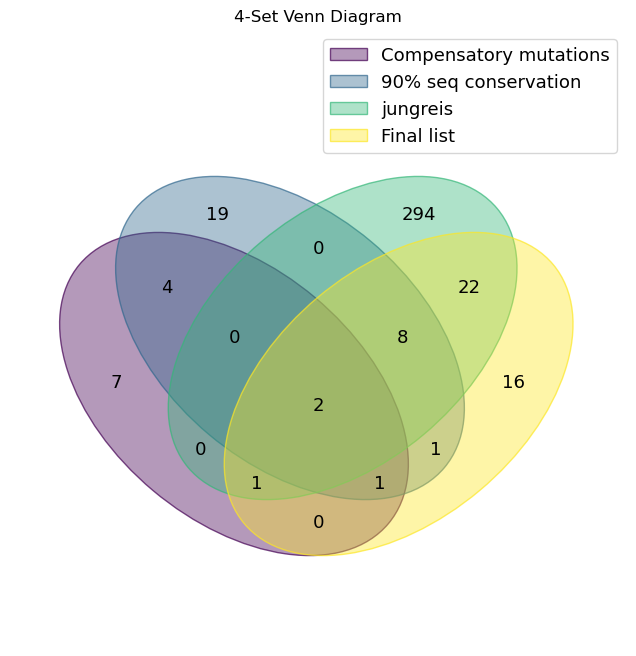

In [17]:
import venn
import matplotlib.pyplot as plt

df_shortlist = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0004_miRNA/data/seqs/shortlist.txt", sep="\t")
df_jungreis= pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0004_miRNA/data/jungreis_genelist_2016_dmle.txt", sep="\t")

#set_codon = set(df_codon)
set_most   = set(df_most)
set_medium = set(df_medium)
set_covariation = set(df_covariation["gene_id"])
set_shortlist = set(df_shortlist["GeneID"])
set_jungreis = set(df_jungreis["Gene ID"])

venn_dict = {
    'Compensatory mutations': set_covariation,
    '90% seq conservation':       set_most,
    'jungreis':     set_jungreis,
    'Final list':       set_shortlist,
}

venn.venn(venn_dict)
plt.title("4-Set Venn Diagram")
plt.show()

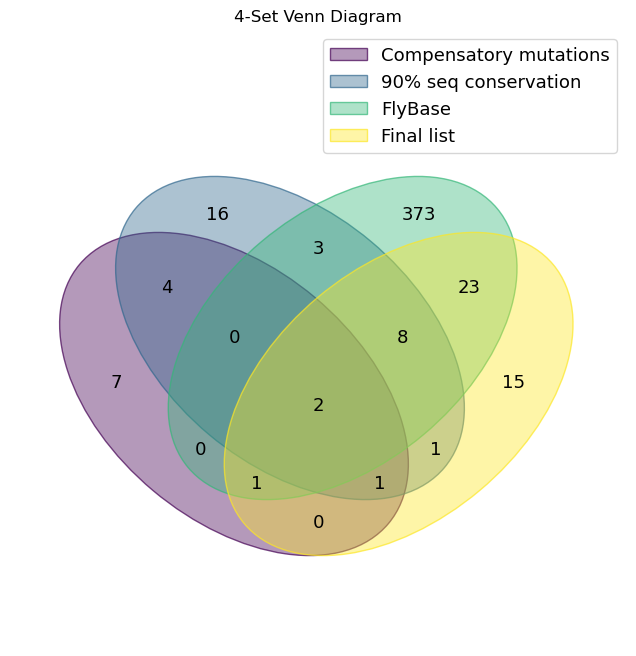

In [22]:
df_flybase = pd.read_csv("/Users/alejandraescos/Documents/github/SCR/0007_miRNA_all/data/FlyBase_IDs-2_Laveena.txt", sep="\t")
df_flybase.columns = ["Gene ID"]

set_most   = set(df_most)
set_medium = set(df_medium)
set_covariation = set(df_covariation["gene_id"])
set_shortlist = set(df_shortlist["GeneID"])
set_flybase = set(df_flybase["Gene ID"])

venn_dict = {
    'Compensatory mutations': set_covariation,
    '90% seq conservation':       set_most,
    'FlyBase':     set_flybase,
    'Final list':       set_shortlist,
}

venn.venn(venn_dict)
plt.title("4-Set Venn Diagram")
plt.show()


### miRNA analysis